# Data v2 Visualization

Inspect images and bounding boxes from the data_v2 dataset to check for data quality issues.

In [1]:
import sys
import random
from pathlib import Path
from collections import Counter

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))

from data import collect_v2_items
from shared.data import load_labels, parse_splits

In [2]:
data_dir = Path("/media/nick/4TB Working 7/Datasets/SKW")
data_v2_dir = Path("/media/nick/4TB Working 7/Datasets/SKW/data_v2")

assert data_dir.exists()
assert data_v2_dir.exists()

## Dataset overview

In [3]:
v2_items = collect_v2_items(data_v2_dir)
print(f"Total data_v2 items: {len(v2_items)}")

# Split counts
split_counts = Counter(split for _, _, split in v2_items)
for split, count in sorted(split_counts.items()):
    print(f"  {split}: {count}")

# Positive vs negative (has label file with boxes vs not)
pos = sum(1 for _, lp, _ in v2_items if lp.exists() and lp.read_text().strip())
print(f"\nPositive (has boxes): {pos} ({pos / len(v2_items) * 100:.1f}%)")
print(
    f"Negative (empty):     {len(v2_items) - pos} ({(len(v2_items) - pos) / len(v2_items) * 100:.1f}%)"
)

Total data_v2 items: 45754
  test: 6578
  train: 32591
  val: 6585

Positive (has boxes): 7665 (16.8%)
Negative (empty):     38089 (83.2%)


In [4]:
# Per-batch breakdown
batch_counts: dict[str, Counter] = {}
for img_path, lbl_path, split in v2_items:
    # Extract batch name from path
    parts = img_path.parts
    if "initial" in parts:
        batch = "initial"
    else:
        idx = parts.index("extra")
        batch = f"extra/{parts[idx + 1]}"
    if batch not in batch_counts:
        batch_counts[batch] = Counter()
    has_boxes = lbl_path.exists() and lbl_path.read_text().strip()
    batch_counts[batch][f"{split}_pos" if has_boxes else f"{split}_neg"] += 1

print(f"{'Batch':<20} {'train':>8} {'val':>8} {'test':>8} {'pos%':>6}")
print("-" * 50)
for batch in sorted(batch_counts):
    c = batch_counts[batch]
    train = c.get("train_pos", 0) + c.get("train_neg", 0)
    val = c.get("val_pos", 0) + c.get("val_neg", 0)
    test = (
        c.get("test_pos", 0)
        + c.get("test_neg", 0)
        + c.get("test_hard_pos", 0)
        + c.get("test_hard_neg", 0)
    )
    total = train + val + test
    pos = sum(v for k, v in c.items() if k.endswith("_pos"))
    pct = pos / total * 100 if total else 0
    print(f"{batch:<20} {train:>8} {val:>8} {test:>8} {pct:>5.1f}%")

Batch                   train      val     test   pos%
--------------------------------------------------
extra/001                  79       24       18  94.2%
extra/002                 379       82       82  18.0%
extra/003                  37        7        9  81.1%
extra/004                 165       36       36   0.0%
extra/005                  90       19       20   0.0%
extra/006                   8        2        2   0.0%
extra/007                  57       12       13   0.0%
extra/008                  14        3        4   0.0%
extra/009                  50       11       11   0.0%
extra/010                 108       23       24   0.0%
extra/011                   7        2        2   0.0%
extra/012                   9        2        3   0.0%
extra/013                  33        7        8   0.0%
extra/014                 106       23       23  60.5%
extra/015                   1        1        1 100.0%
extra/016                  26        6        6   0.0%
extra/017     

## Image size distribution

In [5]:
# Sample image sizes (check a subset for speed)
sample = random.sample(v2_items, min(2000, len(v2_items)))
sizes = []
for img_path, _, _ in sample:
    with Image.open(img_path) as im:
        sizes.append(im.size)  # (w, h)

widths, heights = zip(*sizes)
size_counts = Counter(sizes)
print("Image size distribution (sampled):")
for (w, h), count in size_counts.most_common(10):
    print(f"  {w}x{h}: {count}")

non_square = [(w, h) for w, h in sizes if w != h]
print(f"\nNon-square: {len(non_square)}/{len(sizes)}")
if non_square:
    for w, h in non_square[:5]:
        print(f"  {w}x{h}")

Image size distribution (sampled):
  928x928: 1198
  792x792: 675
  910x910: 78
  790x790: 49

Non-square: 0/2000


## Bounding box statistics

In [6]:
# Analyze bounding boxes across the dataset
all_classes = []
all_widths = []
all_heights = []
all_areas = []
oob_items = []  # out-of-bounds boxes

for img_path, lbl_path, split in v2_items:
    classes, bboxes = load_labels(lbl_path)
    if len(bboxes) == 0:
        continue
    all_classes.extend(classes[:, 0].int().tolist())
    all_widths.extend(bboxes[:, 2].tolist())
    all_heights.extend(bboxes[:, 3].tolist())
    all_areas.extend((bboxes[:, 2] * bboxes[:, 3]).tolist())
    # Check for out-of-bounds
    if (bboxes < -0.01).any() or (bboxes > 1.01).any():
        oob_items.append((img_path, lbl_path, bboxes))

print(f"Total boxes: {len(all_classes)}")
print(f"Class distribution: {Counter(all_classes)}")
print(
    f"\nBox width  (normalized): min={min(all_widths):.4f}, max={max(all_widths):.4f}, mean={np.mean(all_widths):.4f}"
)
print(
    f"Box height (normalized): min={min(all_heights):.4f}, max={max(all_heights):.4f}, mean={np.mean(all_heights):.4f}"
)
print(
    f"Box area   (normalized): min={min(all_areas):.6f}, max={max(all_areas):.4f}, mean={np.mean(all_areas):.4f}"
)
print(f"\nOut-of-bounds boxes: {len(oob_items)} images")
for ip, lp, bb in oob_items[:5]:
    print(f"  {ip.name}: min={bb.min():.3f}, max={bb.max():.3f}")

Total boxes: 16974
Class distribution: Counter({0: 15338, 1: 1630, 2: 6})

Box width  (normalized): min=0.0164, max=0.8126, mean=0.2005
Box height (normalized): min=0.0200, max=0.8851, mean=0.2020
Box area   (normalized): min=0.000472, max=0.4194, mean=0.0460

Out-of-bounds boxes: 0 images


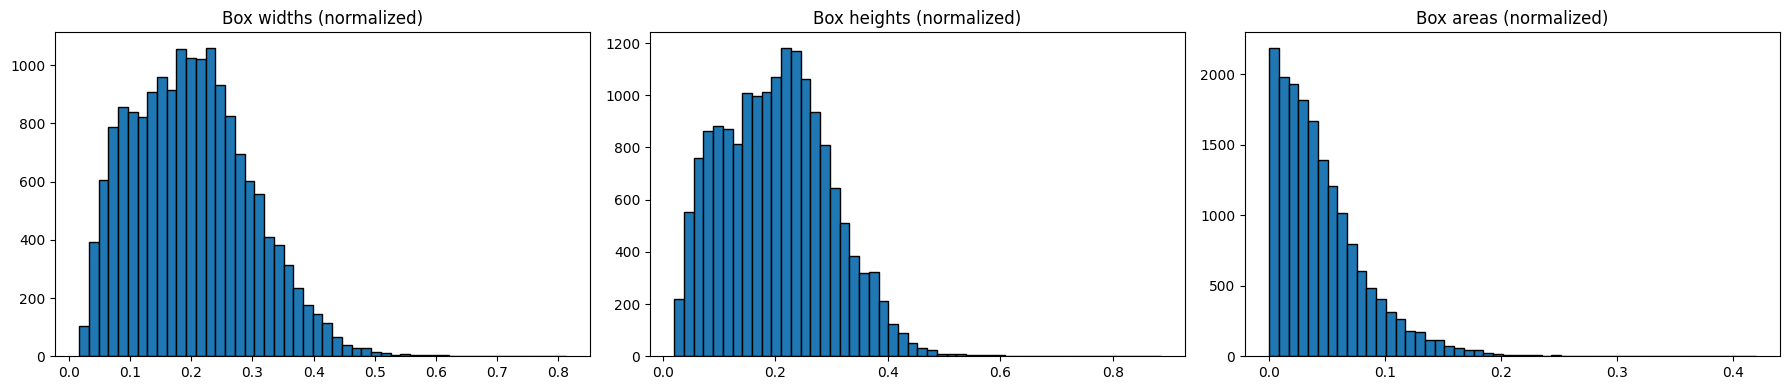

In [7]:
# Box size histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(all_widths, bins=50, edgecolor="black")
axes[0].set_title("Box widths (normalized)")
axes[1].hist(all_heights, bins=50, edgecolor="black")
axes[1].set_title("Box heights (normalized)")
axes[2].hist(all_areas, bins=50, edgecolor="black")
axes[2].set_title("Box areas (normalized)")
plt.tight_layout()
plt.show()

## Visualize random samples with bounding boxes

In [8]:
def show_image_with_boxes(img_path, lbl_path, ax, title=None):
    """Show image with YOLO bounding boxes drawn on it."""
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)

    classes, bboxes = load_labels(lbl_path)
    colors = {0: "#FF4444", 1: "#44FF44"}
    class_names = {0: "skw_0S", 1: "skw_1R"}

    for i in range(len(bboxes)):
        cls = int(classes[i, 0].item())
        xc, yc, bw, bh = bboxes[i].tolist()
        # Convert normalized xywh to pixel xyxy
        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h
        box_w = bw * w
        box_h = bh * h
        color = colors.get(cls, "yellow")
        rect = patches.Rectangle(
            (x1, y1), box_w, box_h, linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            y1 - 2,
            class_names.get(cls, str(cls)),
            color=color,
            fontsize=8,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15", facecolor="black", alpha=0.7),
        )

    label = title or img_path.name
    n_boxes = len(bboxes)
    ax.set_title(f"{label}\n{w}x{h}, {n_boxes} boxes", fontsize=9)
    ax.axis("off")

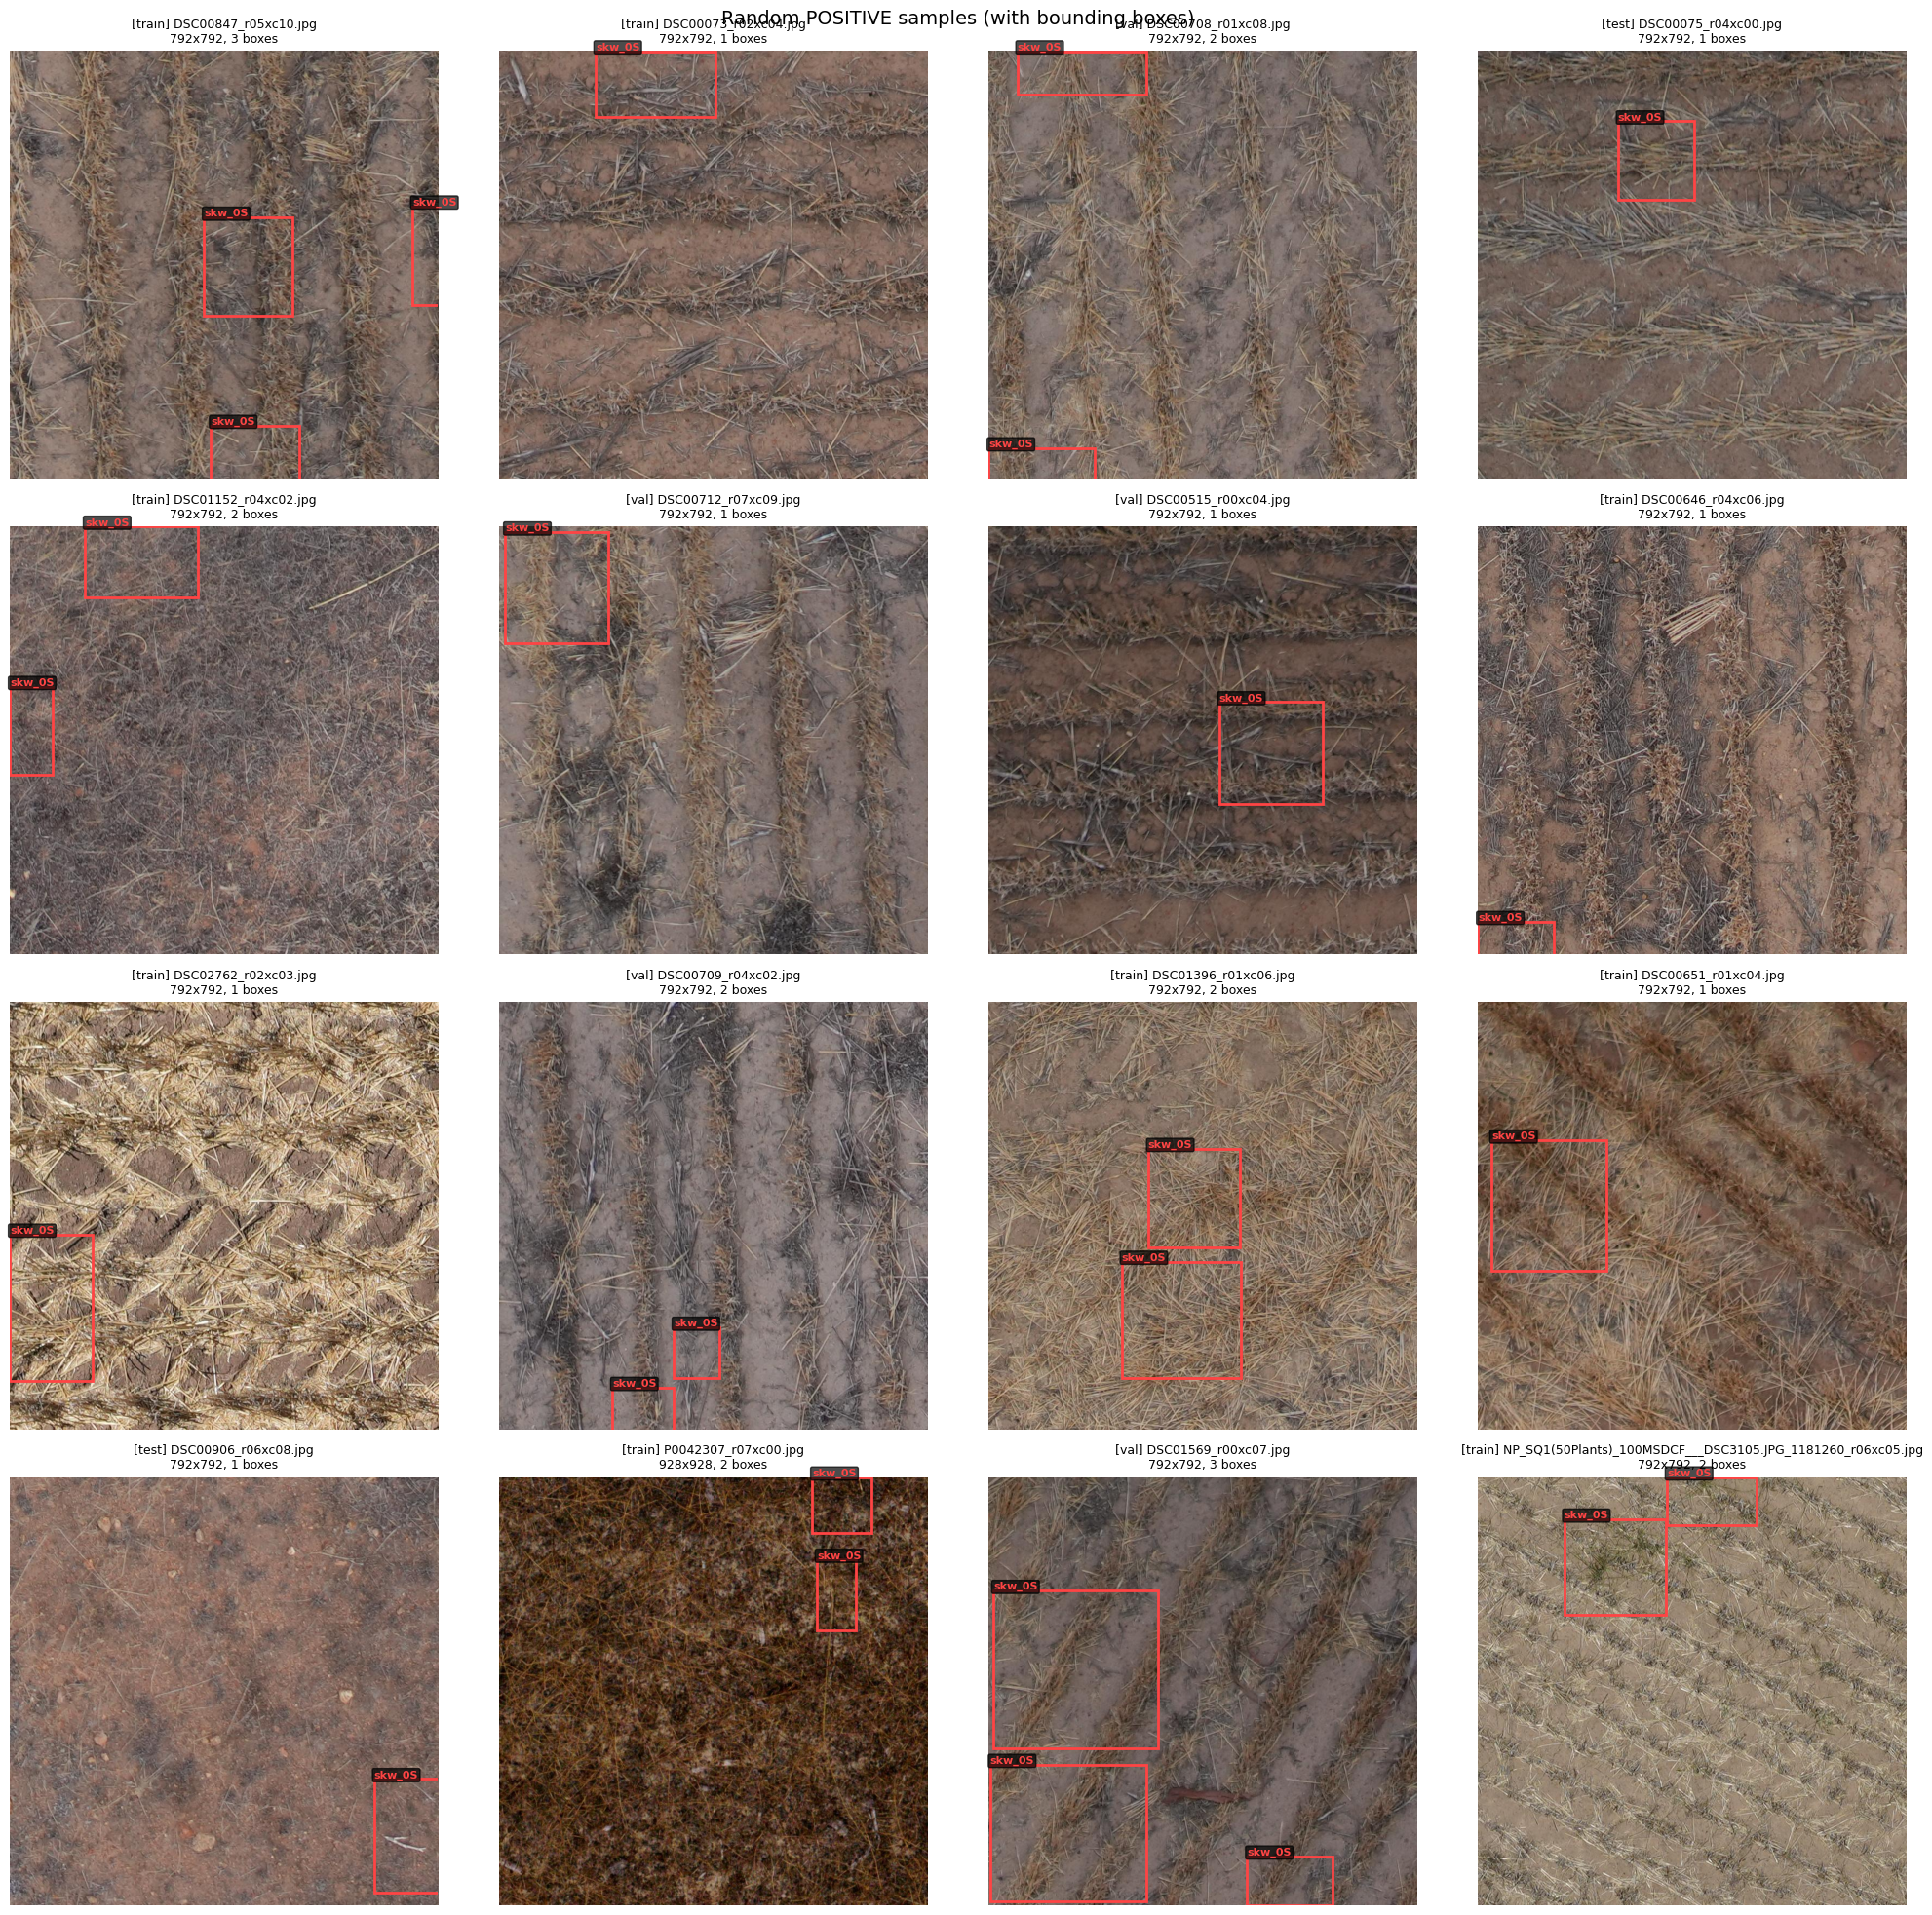

In [9]:
# Random positive samples (images with boxes)
pos_items = [
    (ip, lp, s) for ip, lp, s in v2_items if lp.exists() and lp.read_text().strip()
]
sample_pos = random.sample(pos_items, min(16, len(pos_items)))

n_cols = 4
n_rows = (len(sample_pos) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, (img_path, lbl_path, split) in enumerate(sample_pos):
    show_image_with_boxes(
        img_path, lbl_path, axes[i], title=f"[{split}] {img_path.name}"
    )
for i in range(len(sample_pos), len(axes)):
    axes[i].axis("off")

fig.suptitle("Random POSITIVE samples (with bounding boxes)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Random negative samples (no boxes)
neg_items = [
    (ip, lp, s)
    for ip, lp, s in v2_items
    if not lp.exists() or not lp.read_text().strip()
]
sample_neg = random.sample(neg_items, min(16, len(neg_items)))

n_rows = (len(sample_neg) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, (img_path, lbl_path, split) in enumerate(sample_neg):
    show_image_with_boxes(
        img_path, lbl_path, axes[i], title=f"[{split}] {img_path.name}"
    )
for i in range(len(sample_neg), len(axes)):
    axes[i].axis("off")

fig.suptitle("Random NEGATIVE samples (no bounding boxes)", fontsize=14)
plt.tight_layout()
plt.show()

## Per-batch sample visualization

Show a few positive images from each batch to spot batch-level issues.

In [ ]:
# Group positive items by batch
batch_items: dict[str, list] = {}
for img_path, lbl_path, split in v2_items:
    if not lbl_path.exists() or not lbl_path.read_text().strip():
        continue
    parts = img_path.parts
    if "initial" in parts:
        batch = "initial"
    else:
        idx = parts.index("extra")
        batch = f"extra/{parts[idx + 1]}"
    batch_items.setdefault(batch, []).append((img_path, lbl_path, split))

samples_per_batch = 4
for batch in sorted(batch_items):
    items = batch_items[batch]
    sample = random.sample(items, min(samples_per_batch, len(items)))
    fig, axes = plt.subplots(1, len(sample), figsize=(5 * len(sample), 5))
    if len(sample) == 1:
        axes = [axes]
    for i, (ip, lp, s) in enumerate(sample):
        show_image_with_boxes(ip, lp, axes[i], title=f"[{s}] {ip.name}")
    fig.suptitle(f"Batch: {batch} ({len(items)} positive images)", fontsize=13)
    plt.tight_layout()
    plt.show()

## Outlier detection

Show images with unusually large or many bounding boxes.

In [ ]:
# Find images with most boxes, largest boxes, or suspicious labels
box_info = []
for img_path, lbl_path, split in v2_items:
    classes, bboxes = load_labels(lbl_path)
    if len(bboxes) == 0:
        continue
    areas = (bboxes[:, 2] * bboxes[:, 3]).tolist()
    box_info.append(
        {
            "img_path": img_path,
            "lbl_path": lbl_path,
            "split": split,
            "n_boxes": len(bboxes),
            "max_area": max(areas),
            "mean_area": np.mean(areas),
        }
    )

# Most boxes
by_count = sorted(box_info, key=lambda x: x["n_boxes"], reverse=True)
print("Top 5 by box count:")
for info in by_count[:5]:
    print(f"  {info['n_boxes']:>3} boxes: {info['img_path'].name}")

# Largest single box
by_area = sorted(box_info, key=lambda x: x["max_area"], reverse=True)
print("\nTop 5 by largest box area:")
for info in by_area[:5]:
    print(f"  area={info['max_area']:.4f}: {info['img_path'].name}")

In [ ]:
# Visualize outliers: most boxes
outliers = by_count[:8]
n_cols = 4
n_rows = (len(outliers) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()
for i, info in enumerate(outliers):
    show_image_with_boxes(
        info["img_path"],
        info["lbl_path"],
        axes[i],
        title=f"{info['n_boxes']} boxes\n{info['img_path'].name}",
    )
for i in range(len(outliers), len(axes)):
    axes[i].axis("off")
fig.suptitle("Outliers: most bounding boxes", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Visualize outliers: largest boxes
outliers = by_area[:8]
n_rows = (len(outliers) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()
for i, info in enumerate(outliers):
    show_image_with_boxes(
        info["img_path"],
        info["lbl_path"],
        axes[i],
        title=f"max area={info['max_area']:.3f}\n{info['img_path'].name}",
    )
for i in range(len(outliers), len(axes)):
    axes[i].axis("off")
fig.suptitle("Outliers: largest bounding boxes", fontsize=14)
plt.tight_layout()
plt.show()